In [3]:
from __future__ import division, print_function,  absolute_import
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Flatten, Dense, Dropout, Activation, Conv2D, MaxPooling2D, BatchNormalization
from keras.optimizers import SGD
import keras.backend as K
import keras.utils


In [4]:
import matplotlib.pyplot as plt
import numpy as np

In [5]:
nb_classes = 10
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print("X_train original_shape: ", X_train.shape)
print("y_train original_shape: ", y_train.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
X_train original_shape:  (60000, 28, 28)
y_train original_shape:  (60000,)


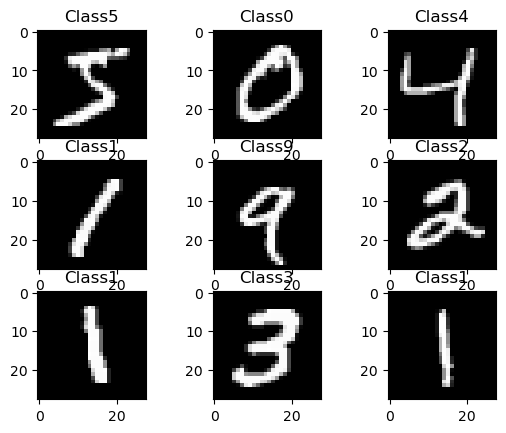

In [6]:
for i in range(9):
    plt.subplot(3,3, i+1)
    plt.imshow(X_train[i], cmap='gray', interpolation=None)
    plt.title('Class{}'.format(y_train[i]))
plt.show()

In [7]:
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255
print("Training matrix shape: ", X_train.shape)
print("Testing matrix shape: ", X_test.shape)


Training matrix shape:  (60000, 784)
Testing matrix shape:  (10000, 784)


In [8]:
def alexnet():
    model = Sequential()
    model.add(Conv2D(64, (3,3), padding='same', input_shape = (28,28,1)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2,2)))

    model.add(Conv2D(128, (7,7), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2,2)))

    model.add(Conv2D(192, (3,3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2,2)))

    model.add(Conv2D(256, (3,3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(1,1)))

    model.add(Flatten())
    model.add(Dense(4096))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dense(4096))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dense(10))
    model.add(BatchNormalization())
    model.add(Activation('softmax'))

    return model



In [14]:
model = alexnet()
optim = SGD(learning_rate=0.0001)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


c:\Users\aazhm\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.fit(X_train.reshape(60000, 28, 28, 1), y_train, batch_size=50, epochs=3, 
          validation_data = (X_test.reshape(10000, 28, 28, 1), y_test), verbose = 1)

Epoch 1/3
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 400s 328ms/step - accuracy: 0.9536 - loss: 0.3742 - val_accuracy: 0.9733 - val_loss: 0.1383
Epoch 2/3
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 399s 332ms/step - accuracy: 0.9865 - loss: 0.1001 - val_accuracy: 0.9883 - val_loss: 0.0535
Epoch 3/3
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 391s 326ms/step - accuracy: 0.9884 - loss: 0.0602 - val_accuracy: 0.9864 - val_loss: 0.0507


## Transfer Learning with Pre trained model

In [1]:
import glob
import numpy as np
import os
import shutil
np.random.seed(42)

In [18]:
files = glob.glob('train/*')
cat_files = [fn for fn in files if 'cat' in fn]
dog_files = [fn for fn in files if 'dog' in fn]


In [19]:
dog_files

['train\\dog.0.jpg',
 'train\\dog.1.jpg',
 'train\\dog.10.jpg',
 'train\\dog.100.jpg',
 'train\\dog.1000.jpg',
 'train\\dog.10000.jpg',
 'train\\dog.10001.jpg',
 'train\\dog.10002.jpg',
 'train\\dog.10003.jpg',
 'train\\dog.10004.jpg',
 'train\\dog.10005.jpg',
 'train\\dog.10006.jpg',
 'train\\dog.10007.jpg',
 'train\\dog.10008.jpg',
 'train\\dog.10009.jpg',
 'train\\dog.1001.jpg',
 'train\\dog.10010.jpg',
 'train\\dog.10011.jpg',
 'train\\dog.10012.jpg',
 'train\\dog.10013.jpg',
 'train\\dog.10014.jpg',
 'train\\dog.10015.jpg',
 'train\\dog.10016.jpg',
 'train\\dog.10017.jpg',
 'train\\dog.10018.jpg',
 'train\\dog.10019.jpg',
 'train\\dog.1002.jpg',
 'train\\dog.10020.jpg',
 'train\\dog.10021.jpg',
 'train\\dog.10022.jpg',
 'train\\dog.10023.jpg',
 'train\\dog.10024.jpg',
 'train\\dog.10025.jpg',
 'train\\dog.10026.jpg',
 'train\\dog.10027.jpg',
 'train\\dog.10028.jpg',
 'train\\dog.10029.jpg',
 'train\\dog.1003.jpg',
 'train\\dog.10030.jpg',
 'train\\dog.10031.jpg',
 'train\\dog.1003

In [20]:
len(cat_files), len(dog_files)

(12500, 12500)

In [21]:
cat_train = np.random.choice(cat_files, size=1500, replace=False)
dog_train = np.random.choice(dog_files, size=1500, replace=False)

#subtract train from original

cat_files = list(set(cat_files) - set(cat_train))
dog_files = list(set(dog_files ) - set(dog_train))


In [22]:
len(cat_train), len(dog_train)

(1500, 1500)

In [23]:
len(cat_files), len(dog_files)

(11000, 11000)

In [ ]:
cat_val = np.random.choice(cat_files, size=500, replace=False)
dog_val = np.random.choice(dog_files, size=500, replace=False)
cat_files = list(set(cat_files) - set(cat_val))
dog_files = list(set(dog_files) - set(dog_val))

In [25]:
len(cat_files), len(dog_files)

(10500, 10500)

In [26]:
len(cat_val), len(dog_val)


(500, 500)

In [27]:
cat_test = np.random.choice(cat_files, size=500, replace=False)
dog_test = np.random.choice(dog_files, size=500, replace=False)
cat_files = list(set(cat_files) - set(cat_test))
dog_files = list(set(dog_files) - set(dog_test))

In [28]:
print('Cat Datasets: ', cat_train.shape, cat_val.shape, cat_test.shape)
print('Dog Datasets: ', dog_train.shape, dog_val.shape, dog_test.shape)

Cat Datasets:  (1500,) (500,) (500,)
Dog Datasets:  (1500,) (500,) (500,)


In [29]:
train_dir = 'training_data'
validation_dir = 'validation_data'
test_dir = 'test_data'

train_files = np.concatenate([cat_train, dog_train])
validate_files = np.concatenate([cat_val, dog_val])
test_files = np.concatenate([cat_test, dog_test])

os.mkdir(train_dir) if not os.path.isdir(train_dir) else None
os.mkdir(validation_dir) if not os.path.isdir(validation_dir) else None
os.mkdir(test_dir) if not os.path.isdir(test_dir) else None

for fn in train_files:
    shutil.copy(fn, train_dir)

for fn in validate_files:
    shutil.copy(fn, validation_dir)

for fn in test_files:
    shutil.copy(fn, test_dir)



## Data Preparation

In [35]:
import glob
import numpy as np
import matplotlib.pyplot as plt
from keras.preprocessing.image import load_img, img_to_array, array_to_img
from tensorflow.keras.preprocessing.image import ImageDataGenerator
%matplotlib inline


In [37]:
IMG_DIM = (150, 150)

train_files = glob.glob('training_data/*')
train_imgs = [img_to_array(load_img(img, target_size=IMG_DIM))
              for img in train_files]
train_imgs = np.array(train_imgs)
train_labels = [fn.split('\\')[1].split('.')[0].strip()
                for fn in train_files]
validate_files = glob.glob('validation_data/*')
validation_imgs = [img_to_array(load_img(img, target_size=IMG_DIM))
                   for img in validate_files]
validation_imgs = np.array(validation_imgs)

validation_labels = [os.path.basename(fn).split('.')[0].strip() for fn in validate_files]


In [39]:
print('Training data shape: ', train_imgs.shape,
      '\t validation data shape: ', validation_imgs.shape)

Training data shape:  (3000, 150, 150, 3) 	 validation data shape:  (1000, 150, 150, 3)


In [40]:
train_imgs_scaled = train_imgs.astype('float32')
validation_imgs_scaled = validation_imgs.astype('float32')
train_imgs_scaled /= 255
validation_imgs_scaled /= 255

(150, 150, 3)


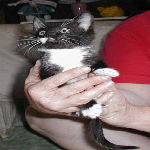

In [41]:
print(train_imgs[1].shape)
array_to_img(train_imgs[300])

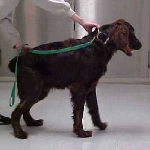

In [42]:
array_to_img(train_imgs[1700])


In [43]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(train_labels)

train_labels_enc = le.fit_transform(train_labels)
validation_labels_enc = le.fit_transform(validation_labels)

print(train_labels[1450:1463])
print(train_labels_enc[1450:1463])

['cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat']
[0 0 0 0 0 0 0 0 0 0 0 0 0]


In [44]:
from keras.applications import vgg16, resnet
from keras.models import Model
import keras
input_shape = (150, 150, 3)

In [46]:
vgg = vgg16.VGG16(include_top=False, weights='imagenet', input_shape = input_shape)
output = vgg.layers[-1].output
output = keras.layers.Flatten() (output)
vgg_model = Model(vgg.input, output)

vgg_model.trainable = False
for layer in vgg_model.layers:
    layer.trainable = False


In [48]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
layers = [(layer, layer.name, layer.trainable) for layer in vgg_model.layers]
pd.DataFrame(layers, columns=['Layer Type', 'Layer Name', 'Layer Trainable'])


,Layer Type,Layer Name,Layer Trainable
0,"<InputLayer name=input_layer_1, built=True>",input_layer_1,False
1,"<Conv2D name=block1_conv1, built=True>",block1_conv1,False
2,"<Conv2D name=block1_conv2, built=True>",block1_conv2,False
3,"<MaxPooling2D name=block1_pool, built=True>",block1_pool,False
4,"<Conv2D name=block2_conv1, built=True>",block2_conv1,False
5,"<Conv2D name=block2_conv2, built=True>",block2_conv2,False
6,"<MaxPooling2D name=block2_pool, built=True>",block2_pool,False
7,"<Conv2D name=block3_conv1, built=True>",block3_conv1,False
8,"<Conv2D name=block3_conv2, built=True>",block3_conv2,False
9,"<Conv2D name=block3_conv3, built=True>",block3_conv3,False


In [53]:
import tensorflow

In [55]:
resnet = tensorflow.keras.applications.ResNet50(include_top=False, weights='imagenet', input_shape = input_shape)
output = resnet.layers[-1].output
output = keras.layers.Flatten()(resnet.output)
resnet_model = Model(resnet.input, output)

resnet_model.trainable = False
for layers in resnet_model.layers:
    layer.trainable = False


In [56]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
layers = [(layer, layer.name, layer.trainable) for layer in resnet_model.layers]
pd.DataFrame(layers, columns=['Layer Type', 'Layer Name', 'Layer Trainable'])


,Layer Type,Layer Name,Layer Trainable
0,"<InputLayer name=input_layer_4, built=True>",input_layer_4,False
1,"<ZeroPadding2D name=conv1_pad, built=True>",conv1_pad,False
2,"<Conv2D name=conv1_conv, built=True>",conv1_conv,False
3,"<BatchNormalization name=conv1_bn, built=True>",conv1_bn,False
4,"<Activation name=conv1_relu, built=True>",conv1_relu,False
...,...,...,...
171,"<Conv2D name=conv5_block3_3_conv, built=True>",conv5_block3_3_conv,False
172,"<BatchNormalization name=conv5_block3_3_bn, built=True>",conv5_block3_3_bn,False
173,"<Add name=conv5_block3_add, built=True>",conv5_block3_add,False
174,"<Activation name=conv5_block3_out, built=True>",conv5_block3_out,False


In [59]:
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, InputLayer
from keras.models import Sequential
from tensorflow.keras import optimizers

modelvgg = Sequential()
modelvgg.add(vgg_model)
modelvgg.add(Dense(512, activation = 'relu', input_dim = input_shape))
modelvgg.add(Dropout(0.3))
modelvgg.add(Dense(512, activation = 'relu'))
modelvgg.add(Dropout(0.3))
modelvgg.add(Dense(1, activation = 'sigmoid'))
modelvgg.compile(loss = 'binary_crossentropy',
                 optimizer = optimizers.RMSprop(learning_rate = 0.0001),
                 metrics = ['accuracy'])
modelvgg.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ functional (Functional)         │ (None, 8192)           │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,172,673 (73.14 MB)

 Trainable params: 4,457,985 (17.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [60]:
historyvgg = modelvgg.fit(x = train_imgs_scaled, y=train_labels_enc,
                          validation_data = (validation_imgs_scaled, validation_labels_enc),
                          batch_size = 20,
                          epochs = 3,
                          verbose = 1)


Epoch 1/3
150/150 ━━━━━━━━━━━━━━━━━━━━ 246s 1s/step - accuracy: 0.7460 - loss: 0.5056 - val_accuracy: 0.8240 - val_loss: 0.3965
Epoch 2/3
150/150 ━━━━━━━━━━━━━━━━━━━━ 216s 1s/step - accuracy: 0.8596 - loss: 0.3075 - val_accuracy: 0.8890 - val_loss: 0.2594
Epoch 3/3
150/150 ━━━━━━━━━━━━━━━━━━━━ 215s 1s/step - accuracy: 0.9084 - loss: 0.2236 - val_accuracy: 0.9000 - val_loss: 0.2551


In [61]:
modelvgg.save("./myVGGmodel.keras")

In [62]:
from tensorflow import keras
modelvgg = keras.models.load_model('./myVGGmodel.keras')
     

3
3
3
3
3


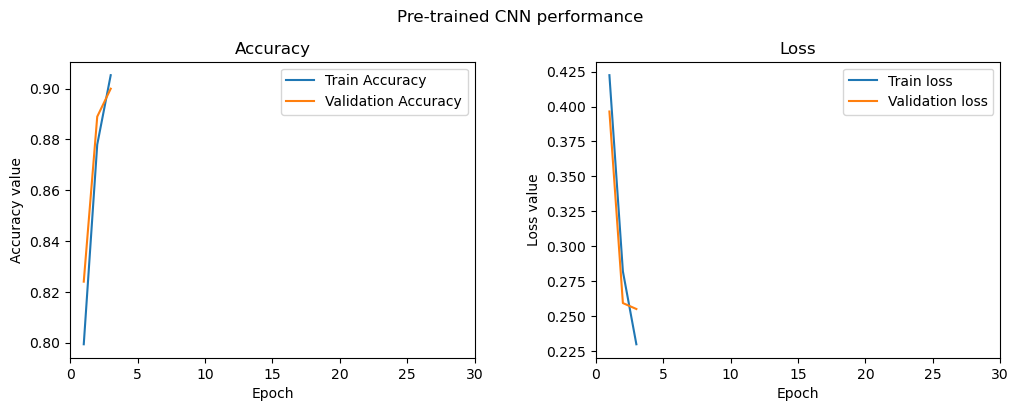

In [66]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize = (12, 4))
t = f.suptitle('Pre-trained CNN performance', fontsize = 12)
f.subplots_adjust(top=0.85, wspace = 0.3)
epoch_list = list(range(1, 4))
print(len(epoch_list))  # Should be 30
print(len(historyvgg.history['accuracy']))  # Should also be 30
print(len(historyvgg.history['val_accuracy']))
print(len(historyvgg.history['loss']))
print(len(historyvgg.history['val_loss']))

ax1.plot(epoch_list, historyvgg.history['accuracy'],
         label = 'Train Accuracy')
ax1.plot(epoch_list, historyvgg.history['val_accuracy'],
         label = 'Validation Accuracy')
ax1.set_xticks(np.arange(0,31,5))
ax1.set_ylabel('Accuracy value')
ax1.set_xlabel('Epoch')
ax1.set_title('Accuracy')
l1 = ax1.legend(loc="best")
ax2.plot(epoch_list, historyvgg.history['loss'], label = 'Train loss')
ax2.plot(epoch_list, historyvgg.history['val_loss'], label = 'Validation loss')
ax2.set_xticks(np.arange(0,31,5))
ax2.set_ylabel('Loss value')
ax2.set_xlabel('Epoch')
ax2.set_title('Loss')
l2 = ax2.legend(loc="best")

 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step
It seems to be a cat


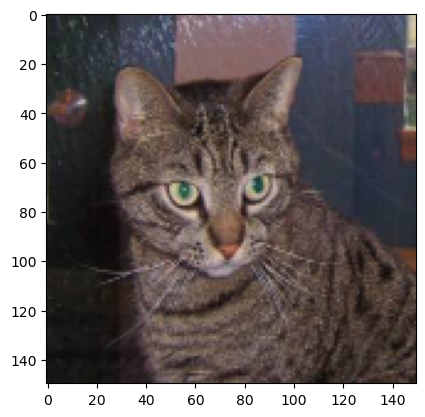

In [70]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg  # ✅ Correct import
from skimage.transform import resize
import numpy as np

# Load the image correctly
cat = mpimg.imread('./train/cat.1.jpg')

# Resize the image
resized_cat = resize(cat, (150, 150, 3))

# Display the image
plt.imshow(resized_cat, cmap='gray')

# Prediction
classes = ['cat', 'dog']
pred = modelvgg.predict(np.expand_dims(resized_cat, axis=0))  # Ensure correct input shape
print("It seems to be a", classes[int(np.round(pred[0][0]))])  # Extract first prediction


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
It seems to be a dog


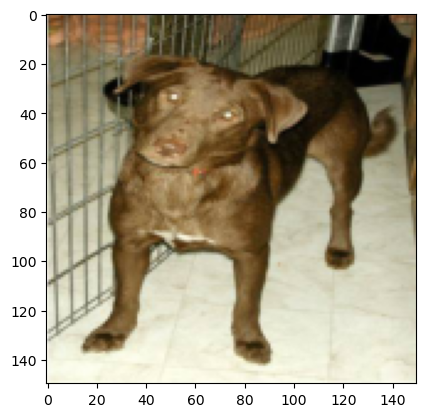

In [71]:
dog = mpimg.imread('./train/dog.1.jpg')

# Resize the image
resized_dog = resize(dog, (150, 150, 3))

# Display the image
plt.imshow(resized_dog, cmap='gray')

# Prediction
classes = ['cat', 'dog']
pred = modelvgg.predict(np.expand_dims(resized_dog, axis=0))  # Ensure correct input shape
print("It seems to be a", classes[int(np.round(pred[0][0]))])  # Extract first prediction